# Medically-Prioritized Cancer Mutation Classification



In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_recall_curve
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


## 1. High-Confidence Data Loading

Loading 1M rows with expert/multi-lab consensus labels (2-4 stars).

In [8]:
DATA_PATH = "../data/variant_summary.txt"
COLUMNS_TO_USE = ['Type', 'Chromosome', 'PositionVCF', 'ReferenceAlleleVCF', 'AlternateAlleleVCF', 'ClinSigSimple', 'Assembly', 'GeneID', 'NumberSubmitters', 'ReviewStatus', 'VariationID']

reader = pd.read_csv(DATA_PATH, sep='\t', usecols=COLUMNS_TO_USE, chunksize=100000, low_memory=False)
data_list = []

high_quality_status = [
    'criteria provided, multiple submitters, no conflicts',
    'reviewed by expert panel',
    'practice guideline'
]

for chunk in reader:
    clean = chunk[
        (chunk['Assembly'] == 'GRCh38') & 
        (chunk['ClinSigSimple'].isin([0, 1])) & 
        (chunk['ReviewStatus'].isin(high_quality_status))
    ].dropna()
    data_list.append(clean)
    if sum(len(d) for d in data_list) >= 1000000:
        break

df = pd.concat(data_list).reset_index(drop=True)
df = df.drop_duplicates(subset=['VariationID'])
print(f"Dataset processed: {df.shape}")

Dataset processed: (674256, 11)


## 2. Feature Engineering & Weight Calculation

In [9]:
gene_le = LabelEncoder()
df['GeneIdx'] = gene_le.fit_transform(df['GeneID'].astype(str))
type_le = LabelEncoder()
df['TypeIdx'] = type_le.fit_transform(df['Type'].astype(str))
chrom_le = LabelEncoder()
df['ChromIdx'] = chrom_le.fit_transform(df['Chromosome'].astype(str))

status_map = {'criteria provided, multiple submitters, no conflicts': 2, 'reviewed by expert panel': 3, 'practice guideline': 4}
df['Stars'] = df['ReviewStatus'].map(status_map).fillna(1)

def encode_nuc(seq): mapping = {'A':1,'C':2,'G':3,'T':4}; return mapping.get(str(seq)[:1], 0)
df['RefEncoded'] = df['ReferenceAlleleVCF'].apply(encode_nuc)
df['AltEncoded'] = df['AlternateAlleleVCF'].apply(encode_nuc)

X_num = df[['PositionVCF', 'RefEncoded', 'AltEncoded', 'NumberSubmitters', 'Stars']].values
X_gene = df['GeneIdx'].values
X_type = df['TypeIdx'].values
X_chrom = df['ChromIdx'].values
y = df['ClinSigSimple'].values

X_n_tr, X_n_te, X_g_tr, X_g_te, X_t_tr, X_t_te, X_c_tr, X_c_te, y_tr, y_te = train_test_split(
    X_num, X_gene, X_type, X_chrom, y, test_size=0.15, random_state=42, stratify=y
)

scaler = StandardScaler()
X_n_tr = scaler.fit_transform(X_n_tr)
X_n_te = scaler.transform(X_n_te)

# --- CUSTOM MEDICAL WEIGHTS ---
# We force Pathogenic (Class 1) to be much more important than Benign (Class 0)
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weight_dict = {0: weights[0], 1: weights[1] * 1.5} # Extra 1.5x boost to Pathogenic for safety
print(f"Class Weights: {class_weight_dict}")

Class Weights: {0: np.float64(0.5843541299183295), 1: np.float64(5.195544045834744)}


## 3. Medical-Focused Model Architecture

Added `Recall` and `Precision` metrics to track performance on dangerous mutations.

In [10]:
ins = [layers.Input(shape=(1,)), layers.Input(shape=(1,)), layers.Input(shape=(1,)), layers.Input(shape=(5,))]
g_emb = layers.Flatten()(layers.Embedding(len(gene_le.classes_), 64)(ins[0]))
t_emb = layers.Flatten()(layers.Embedding(len(type_le.classes_), 16)(ins[1]))
c_emb = layers.Flatten()(layers.Embedding(len(chrom_le.classes_), 16)(ins[2]))

merged = layers.Concatenate()([g_emb, t_emb, c_emb, ins[3]])

x = layers.Dense(512, activation='relu')(merged)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=ins, outputs=output)
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy', metrics.Recall(name='recall'), metrics.Precision(name='precision')]
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 64)     │    656,704 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 16)     │        160 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 1, 16)     │        400 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 64)        │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 16)        │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 16)        │          0 │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 101)       │          0 │ flatten_3[0][0],  │
│ (Concatenate)       │                   │            │ flatten_4[0][0],  │
│                     │                   │            │ flatten_5[0][0],  │
│                     │                   │            │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 512)       │     52,224 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │    131,328 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │     32,896 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 64)        │      8,256 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1)         │         65 │ dense_9[0][0]   

 Total params: 885,105 (3.38 MB)

 Trainable params: 883,569 (3.37 MB)

 Non-trainable params: 1,536 (6.00 KB)

## 4. Weighted Training for Sensitivity

In [11]:
lr_cb = callbacks.ReduceLROnPlateau(monitor='val_recall', mode='max', factor=0.5, patience=3, min_lr=1e-5)
stop_cb = callbacks.EarlyStopping(monitor='val_recall', mode='max', patience=10, restore_best_weights=True)

history = model.fit(
    [X_g_tr, X_t_tr, X_c_tr, X_n_tr], y_tr,
    validation_split=0.15,
    epochs=50,
    batch_size=2048,
    class_weight=class_weight_dict,
    callbacks=[lr_cb, stop_cb]
)

Epoch 1/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.7274 - loss: 0.5661 - precision: 0.3265 - recall: 0.8292 - val_accuracy: 0.8472 - val_loss: 0.4864 - val_precision: 0.4741 - val_recall: 0.7275 - learning_rate: 0.0010
Epoch 2/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7553 - loss: 0.5000 - precision: 0.3575 - recall: 0.8645 - val_accuracy: 0.7807 - val_loss: 0.4565 - val_precision: 0.3760 - val_recall: 0.8328 - learning_rate: 0.0010
Epoch 3/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7633 - loss: 0.4808 - precision: 0.3668 - recall: 0.8733 - val_accuracy: 0.7717 - val_loss: 0.4769 - val_precision: 0.3667 - val_recall: 0.8434 - learning_rate: 0.0010
Epoch 4/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7691 - loss: 0.4645 - precision: 0.3737 - recall: 0.8793 - val_accuracy: 0.7714 - val_loss: 0.4815 - val_precision: 0.3663 - val_recall: 0.8430 - learning_rate: 0.0010
Epoch 5/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accur

## 5. Medical Utility Analysis (Threshold Tuning)


3161/3161 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
Optimized Medical Threshold: 0.4996

Classification Report (Medical Sensitivity Adjusted):
              precision    recall  f1-score   support

           0       0.97      0.75      0.84     86539
           1       0.36      0.85      0.51     14600

    accuracy                           0.76    101139
   macro avg       0.66      0.80      0.67    101139
weighted avg       0.88      0.76      0.79    101139



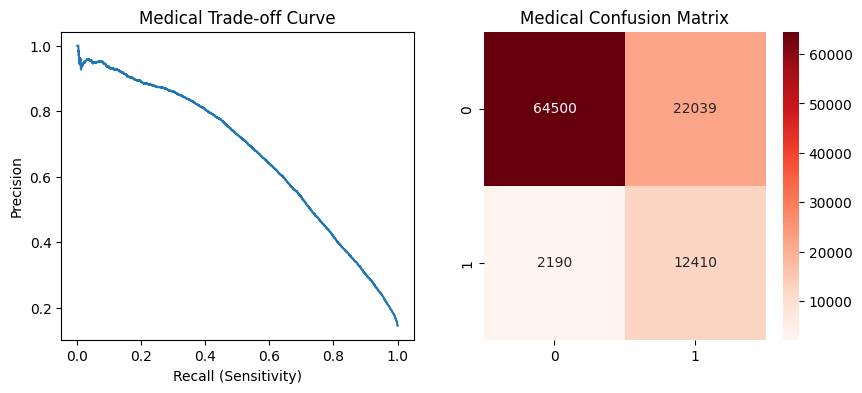

In [12]:
y_probs = model.predict([X_g_te, X_t_te, X_c_te, X_n_te])

# Find threshold for ~85% Recall
precisions, recalls, thresholds = precision_recall_curve(y_te, y_probs)
target_recall = 0.85
idx = np.where(recalls >= target_recall)[0][-1] # Last index where recall is still above target
medical_threshold = thresholds[idx]

print(f"Optimized Medical Threshold: {medical_threshold:.4f}")

y_p_custom = (y_probs >= medical_threshold).astype(int)

print("\nClassification Report (Medical Sensitivity Adjusted):")
print(classification_report(y_te, y_p_custom))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(recalls, precisions)
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Medical Trade-off Curve')

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_te, y_p_custom), annot=True, fmt='d', cmap='Reds')
plt.title('Medical Confusion Matrix')
plt.show()